# FaceDetector Processing

---

Tahapan ini mencakup pengambilan, pemrosesan dan evaluasi untuk skenario tugas dan istirahat
- Mengambil data dari file npy
- Melakukan pre-processing pada sinyal rPPG dan PPG
- Melakukan extraksi HR dan HRV (SDNN dan RMSSD)
- Evaluasi MAE, RMSE dan PC

In [2]:
## Importing Dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import neurokit2 as nk
import scipy
import os
from prettytable import PrettyTable
from dataclasses import dataclass
from sklearn.metrics import mean_absolute_error
from scipy.stats import pearsonr
import numpy as np


In [3]:
@dataclass
class SignalData:
    subject: str
    task: str
    method: str  # PPG / POS / LGI / GREEN / CHROM / OMIT
    raw: np.ndarray
    fs: int
    preprocessed: np.ndarray = None


## Preprocessing & Signal Extraction

### Define the processing method (Preprocess, Ekstraksi HR / HRV Metrik Pipeline)
---

In [4]:
def preprocess_rppg(rppg_signal, ppg_signal, fs_rppg=35, fs_ppg=64,):
    # Time bases
    t_rppg = np.arange(len(rppg_signal)) / fs_rppg
    t_ppg  = np.arange(len(ppg_signal)) / fs_ppg

    # Interpolation to PPG Samples Length
    cs = scipy.interpolate.CubicSpline(t_rppg, rppg_signal)
    rppg_up = cs(t_ppg)

    # Bandpass filter rPPG
    b, a = scipy.signal.butter(3, [0.7, 2.5], btype='band', fs=fs_ppg)
    rppg_filtered = scipy.signal.filtfilt(b, a, rppg_up)

    # Normalize signals
    rppg_filtered = (rppg_filtered - np.mean(rppg_filtered)) / np.std(rppg_filtered)

    return rppg_filtered


In [5]:
def preprocess_ppg(ppg_signal, fs_ppg=64):

    # Bandpass filter the PPG signal
    b, a = scipy.signal.butter(3, [0.7, 2.5], btype='band', fs=fs_ppg)
    ppg_filtered = scipy.signal.filtfilt(b, a, ppg_signal)

    # Normalize the signal
    ppg_filtered = (ppg_filtered - np.mean(ppg_filtered)) / np.std(ppg_filtered)

    return ppg_filtered


Main Methods

---

Opening the npy files for FaceDetector

In [6]:
root_path = "dataset_numpy"
subjects = ["s41", "s42", "s43", "s44","s45","s46","s47","s48","s49","s50","s51","s52", "s53","s54","s55","s56"]
tasks = ["T1", "T3"] # Rest, Task

sample_rate_gt = 64  # Hz
sample_rate_video = 35 # Hz

all_signals = []

for subject in subjects:
    for task in tasks:
        # --- Ground truth PPG ---
        gt_file = os.path.join(root_path, subject, f"bvp_{subject}_{task}.csv")
        gt_data = pd.read_csv(gt_file, header=None).values.flatten()
        gt_signal = preprocess_ppg(gt_data, fs_ppg=sample_rate_gt)

        all_signals.append(
            SignalData(
                subject=subject,
                task=task,
                method="PPG",
                raw=gt_data,
                fs=sample_rate_gt,
                preprocessed=gt_signal
            )
        )

        # --- rPPG methods ---
        for method in ["POS", "LGI", "OMIT", "GREEN", "CHROM"]:
            file_path = os.path.join(root_path, subject, f"Landmark_{subject}_{task}_{method}_rppg.npy")
            rppg_raw = np.load(file_path)

            rppg_preproc = preprocess_rppg(rppg_raw, gt_data,
                                           fs_rppg=sample_rate_video,
                                           fs_ppg=sample_rate_gt)

            all_signals.append(
                SignalData(
                    subject=subject,
                    task=task,
                    method=method,
                    raw=rppg_raw,
                    fs=sample_rate_video,
                    preprocessed=rppg_preproc
                )
            )

## Sanity check the pipeline for the result
## Expected all methods should have length of 11520 (64 Hz * 180 sec = 11520 samples long)
summary = pd.DataFrame([{
    "Subject": sig.subject,
    "Task": sig.task,
    "Method": sig.method,
    "RawLen": len(sig.raw),
    "PreprocLen": len(sig.preprocessed)
} for sig in all_signals])

print(summary.head(20))


   Subject Task Method  RawLen  PreprocLen
0      s41   T1    PPG   11520       11520
1      s41   T1    POS    6325       11520
2      s41   T1    LGI    6325       11520
3      s41   T1   OMIT    6325       11520
4      s41   T1  GREEN    6325       11520
5      s41   T1  CHROM    6325       11520
6      s41   T3    PPG   11520       11520
7      s41   T3    POS    6325       11520
8      s41   T3    LGI    6325       11520
9      s41   T3   OMIT    6325       11520
10     s41   T3  GREEN    6325       11520
11     s41   T3  CHROM    6325       11520
12     s42   T1    PPG   11520       11520
13     s42   T1    POS    6325       11520
14     s42   T1    LGI    6325       11520
15     s42   T1   OMIT    6325       11520
16     s42   T1  GREEN    6325       11520
17     s42   T1  CHROM    6325       11520
18     s42   T3    PPG   11520       11520
19     s42   T3    POS    6325       11520


Notes:

---

The signal been in the same length and preprocessed

and it's fine to move on to the HR / HRV Extraction

## Evaluasi Performa rPPG
---

Tahapan ini akan mengukur HR / HRV dari rPPG dan PPG

In [7]:
@dataclass
class MetricData:
    subject: str
    task: str
    method: str
    hr: float
    sdnn: float
    rmssd: float


**Formula Perhitungan HR dan HRV**

**Heart Rate (HR):**
$$
HR = \frac{60}{\overline{RR}}
$$
- $\overline{RR}$ = rata-rata interval RR (detik) antar puncak sinyal

**SDNN (Standard Deviation of NN intervals):**
$$
SDNN = \text{std}(RR_{ms})
$$
- $(RR_{ms})$ = interval RR dalam milidetik

**RMSSD (Root Mean Square of Successive Differences):**
$$
RMSSD = \sqrt{\frac{1}{N-1} \sum_{i=1}^{N-1} (RR_{ms,i+1} - RR_{ms,i})^2}
$$
- $(RR_{ms,i})$ = interval RR ke-i dalam milidetik
- $(N)$ = jumlah interval RR valid

**Langkah:**
1. Deteksi puncak sinyal (peak detection)
2. Hitung interval RR antar puncak: $(RR = \frac{\Delta \text{peak}}{fs})$
3. Bersihkan RR di luar rentang 0.3–2.0 detik
4. Konversi RR ke milidetik: $(RR_{ms} = RR \times 1000)$
5. Hitung HR, SDNN, RMSSD dengan rumus

In [8]:
## Define the method to compute the metrics
## This method will takes any signal (rPPG, PPG) 
# and it's sampling rate to get the HR and HRv
def compute_metrics(signal, fs):
    ## Compute the HR
    peaks , _ = scipy.signal.find_peaks(signal, prominence=0.5)

    ## Getting the RR Interval / Jeda Waktu antar Puncak / Beat
    rr_intervals = np.diff(peaks) / fs  # Convert to unit seconds

    ## Clean the RR
    rr = np.asarray(rr_intervals, dtype=float)
    rr_intervals = rr[( rr >= 0.3 ) & (rr <= 2.0)] # Clean RR interval outside 0.3 - 2.0 seconds

    ## Calculating the HR
    hr = int(60 / np.mean(rr_intervals))

    ## Converting RR interval for milis for HRV analysis
    rr_intervals_ms = rr_intervals * 1000  # Convert to milliseconds

    ## Calculating the HRV (SDNN, RMSSD)
    ## Casting to Int for easier interpretation
    sdnn = int(np.std(rr_intervals_ms))
    rmssd = int(np.sqrt(np.mean(np.square(np.diff(rr_intervals_ms)))))

    return hr, sdnn, rmssd

**Create a Header Template for HR, HRV**

---

Membuat header template agar tabel lebih padat dan bisa memuat banyak informasi, akan ada 3 tabel (HR, SDNN, RMSSD), dikelompokan berdasarkan 
- Tipe skenario
- Metode pengukuran data

In [9]:
arrays = [
    [""] + ["Rest"]*6 + ["Task"]*6,
    ["Subject", "GT", "POS", "GREEN", "LGI", "OMIT", "CHROM",
     "GT", "POS", "GREEN", "LGI", "OMIT", "CHROM"]
]


columns = pd.MultiIndex.from_arrays(arrays)

In [10]:
all_metrics = []

for sig in all_signals:
    hr, sdnn, rmssd = compute_metrics(sig.preprocessed, 64)
    all_metrics.append(MetricData(sig.subject, sig.task, sig.method, hr, sdnn, rmssd))


In [11]:
df_metrics = pd.DataFrame([{
    "Subject": metrics.subject,
    "Task": metrics.task,
    "Method": metrics.method,
    "HR": metrics.hr,
    "SDNN": metrics.sdnn,
    "RMSSD": metrics.rmssd
} for metrics in all_metrics])


#### Ekstraksi HR

---

In [12]:
rows = []

for subject in subjects:
    row = [subject]
    # Rest (T1) HR
    for method in ["PPG", "POS", "GREEN", "LGI", "OMIT", "CHROM"]:
        val = df_metrics.query("Subject == @subject and Task == 'T1' and Method == @method")["HR"]
        row.append(val.values[0] if len(val) > 0 else None)
    # Task (T3) HR
    for method in ["PPG", "POS", "GREEN", "LGI", "OMIT", "CHROM"]:
        val = df_metrics.query("Subject == @subject and Task == 'T3' and Method == @method")["HR"]
        row.append(val.values[0] if len(val) > 0 else None)

    rows.append(row)

df_hr = pd.DataFrame(rows, columns=columns)
df_hr

Rest                           Task                         
   Subject   GT POS GREEN  LGI OMIT CHROM   GT POS GREEN LGI OMIT CHROM
0      s41   96  92    90   94   95    95   74  91    68  91   88    90
1      s42   70  73    70   70   70    72   83  81    68  69   70    75
2      s43   95  90    80   89   89    91   84  77    61  76   72    81
3      s44   63  68    64   65   65    65   65  56    55  54   58    55
4      s45   77  75    65   73   73    75   83  71    58  62   62    71
5      s46   74  75    74   74   74    74   88  81    72  83   82    85
6      s47   77  76    72   77   77    77   78  70    46  47   53    42
7      s48   65  70    66   71   71    71   75  69    64  69   69    67
8      s49  101  97    98  100  100   100   70  72    58  69   69    69
9      s50  103  93    81   96   96    94  103  91    65  93   93    94
10     s51   62  63    63   62   62    62   72  74    58  71   71    68
11     s52   78  87    80   87   87    88   74  79    66  80   79    79
12     s53   64  84    83   85   85    84   68  75    65  72   72    72
13     s54   87  89    61   89   89    88   90  81    67  78   78    83
14     s55   88  58    46   49   43    50   86  81    67  75   75    74
15     s56   71  58    42   42   42    44   75  66    41  41   41    42

#### Evaluasi HR (MAE, RMSE dan PC)

---

- **MAE** dan **RMSE** digunakan untuk mengukur seberapa besar perbedaan nilai HR antara hasil estimasi rPPG dan referensi PPG.
- **PC (Pearson Correlation)** digunakan untuk melihat tren atau korelasi antara hasil pengukuran HR dari rPPG dan PPG.

In [13]:
methods = ["POS", "GREEN", "LGI", "OMIT", "CHROM"]
conditions = ["Rest", "Task"]

eval_results = []

for cond in conditions:
    gt = df_hr[(cond, "GT")]  # ground truth for this condition
    for method in methods:
        row=[method]
        pred = df_hr[(cond, method)]
        
        mae = mean_absolute_error(gt, pred)
        rmse = np.sqrt(np.mean((gt - pred) ** 2))
        pc, _ = pearsonr(gt, pred)
        
        eval_results.append({
            "Condition": cond,
            "Method": method,
            "MAE": mae,
            "RMSE": rmse,
            "PC": pc
        })

eval_df_hr = pd.DataFrame(eval_results)
print("HR (satuan: BPM)")
eval_df_hr

HR (satuan: BPM)


,Condition,Method,MAE,RMSE,PC
0,Rest,POS,7.1875,10.538619,0.673370
1,Rest,GREEN,11.5000,16.904142,0.444290
2,Rest,LGI,8.0000,13.770439,0.596635
3,Rest,OMIT,8.3125,14.863966,0.559963
4,Rest,CHROM,7.6875,13.278272,0.606115
5,Task,POS,7.4375,8.400149,0.636165
6,Task,GREEN,18.0625,20.644309,0.353344
7,Task,LGI,12.0000,15.223337,0.469459
8,Task,OMIT,11.3750,14.274102,0.482434
9,Task,CHROM,10.6875,14.497845,0.536447


**Visualisasi Hasil MAE, RMSE dan PC**

---

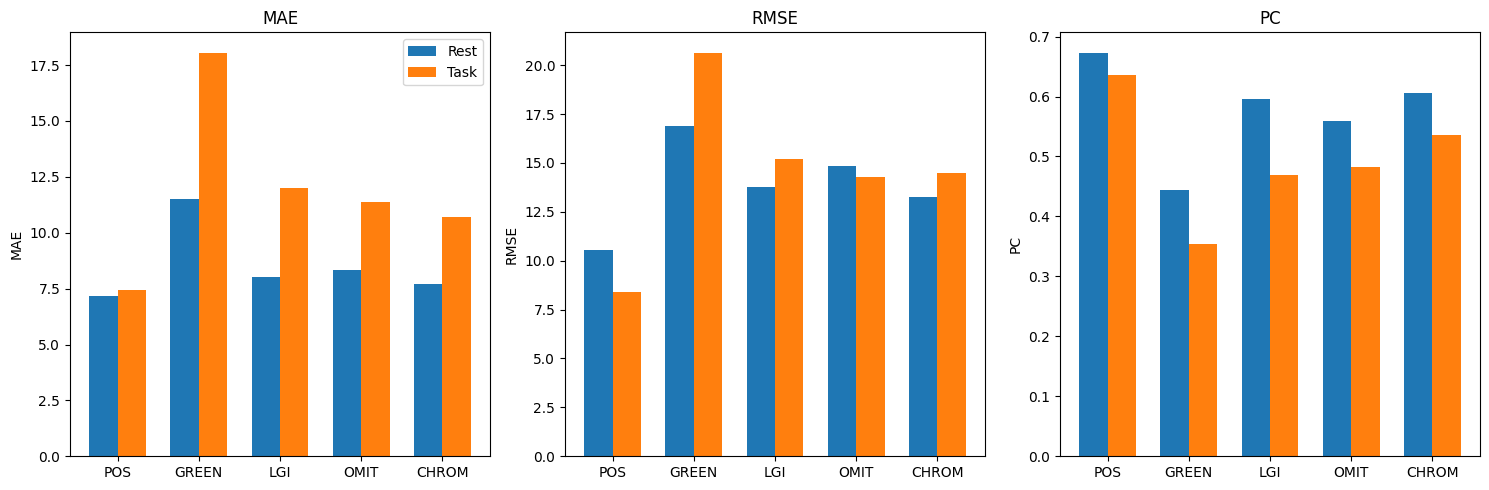

In [14]:
metrics = ["MAE", "RMSE", "PC"]
methods = ["POS", "GREEN", "LGI", "OMIT", "CHROM"]
x = range(len(methods))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, metric in enumerate(metrics):
    ax = axes[idx]
    rest_vals = eval_df_hr[eval_df_hr["Condition"]=="Rest"][metric]
    task_vals = eval_df_hr[eval_df_hr["Condition"]=="Task"][metric]
    ax.bar([i-width/2 for i in x], rest_vals, width, label="Rest")
    ax.bar([i+width/2 for i in x], task_vals, width, label="Task")
    ax.set_xticks(x)
    ax.set_xticklabels(methods)
    ax.set_ylabel(metric)
    ax.set_title(metric)
    if idx == 0:
        ax.legend()
plt.tight_layout()
plt.show()

| Method | MAE (Rest) | RMSE (Rest) | PC (Rest) | MAE (Task) | RMSE (Task) | PC (Task) |
|--------|------------|-------------|-----------|------------|-------------|-----------|
| POS    | 4.4375     | 7.335700    | 0.890876  | 6.8125     | 9.775607    | 0.667658  |
| GREEN  | 7.8750     |10.191909    | 0.698441  |10.2500     |13.697628    | 0.250453  |
| LGI    | 3.6875     | 6.562202    | 0.897551  | 8.1875     |13.695346    | 0.321868  |
| OMIT   | 3.6875     | 6.562202    | 0.897551  | 8.1875     |13.736357    | 0.322018  |
| CHROM  | 4.1250     | 6.698881    | 0.908825  | 7.1875     | 9.450529    | 0.600982  |

**Observation**

---

- Pada kondisi istirahat, rPPG dapat mengukur HR (detak jantung) dengan cukup stabil dan konsistensi yang tinggi terhadap hasil HR dari PPG, dengan nilai MAE < 5 (stabilitas) dan PC > 0.8 (konsistensi) baik.
- Sebaliknya, pada tugas mental, pengukuran HR (detak jantung) relatif kurang stabil dengan error yang meningkat (MAE dan RMSE lebih tinggi), dan korelasi (PC) yang menurun, menandakan reliabilitas rPPG berkurang dalam mengukur detak jantung (HR), karena pada tugas mental, tidak sepenuhnya subjek diam, penurunan performa ini kemungkinan disebabkan oleh gerakan wajah, ekspresi dan pencahayaan yang lebih bervariasi dibandingkan saat kondisi istirahat, dimana subjek relatif diam. 
- Secara umum, dalam studi biomedis, MAE < 5 bpm dan RMSE < 8 bpm dianggap cukup baik untuk estimasi HR dari video, serta PC > 0.8 (baik) dan > 0.6 (moderat) [[0]](https://biomedical-engineering-online.biomedcentral.com/articles/10.1186/s12938-025-01405-5?utm_source=chatgpt.com).
- Dari hasil evaluasi, metode POS dan CHROM terbukti paling robust di kedua skenario (Rest dan Task), dengan error rendah dan konsistensi tren pengukuran HR terhadap PPG (PC > 0.6, kategori moderat hingga baik).

#### Ekstraksi HRV (SDNN)

In [15]:
rows = []

for subject in subjects:
    row = [subject]
    # Rest (T1) SDNN
    for method in ["PPG", "POS", "GREEN", "LGI", "OMIT", "CHROM"]:
        val = df_metrics.query("Subject == @subject and Task == 'T1' and Method == @method")["SDNN"]
        row.append(val.values[0] if len(val) > 0 else None)
    # Task (T3) SDNN
    for method in ["PPG", "POS", "GREEN", "LGI", "OMIT", "CHROM"]:
        val = df_metrics.query("Subject == @subject and Task == 'T3' and Method == @method")["SDNN"]
        row.append(val.values[0] if len(val) > 0 else None)

    rows.append(row)

df_sdnn = pd.DataFrame(rows, columns=columns)
print("SDNN (Satuan: ms)")
df_sdnn


SDNN (Satuan: ms)


Rest                            Task                           
   Subject   GT  POS GREEN  LGI OMIT CHROM   GT  POS GREEN  LGI OMIT CHROM
0      s41   54  135   160  104   99   104  264  199   295  187  201   193
1      s42  110  166   192  192  192   182  185  272   318  317  318   256
2      s43   45  150   258  141  141   136  178  258   327  274  290   217
3      s44  141  258   214  211  211   211  220  305   250  368  303   327
4      s45  100  165   280  175  174   166  115  283   321  325  326   292
5      s46   59   91    61   66   66   113  104  214   267  176  185   175
6      s47   90  106   191   87   87    92  281  314   102  102  325     7
7      s48  314  158   249  154  153   160  300  325   336  280  279   329
8      s49   44  135   102   66   66    59  313  291   317  306  285   297
9      s50   28  178   265  156  156   166   86  184   332  171  171   166
10     s51   80  121   140  104  104   121  139  184   322  208  212   228
11     s52  190  147   178  146  146   132  237  223   289  220  221   229
12     s53  114  163   146  143  143   146  265  231   291  200  200   237
13     s54  152  145   368  150  151   159  117  257   340  264  271   249
14     s55  166  395   238  232    7   273  130  295   366  310  308   354
15     s56  312  373     7    7    7    54  262  452   171  171  171    44

#### Evaluasi SDNN (MAE, RMSE dan PC)

---

- **MAE** dan **RMSE** digunakan untuk mengukur seberapa besar perbedaan nilai SDNN antara hasil estimasi rPPG dan referensi PPG.
- **PC (Pearson Correlation)** digunakan untuk melihat tren atau korelasi antara hasil pengukuran SDNN dari rPPG dan PPG.

In [16]:
methods = ["POS", "GREEN", "LGI", "OMIT", "CHROM"]
conditions = ["Rest", "Task"]

eval_results = []

for cond in conditions:
    gt = df_sdnn[(cond, "GT")]  # ground truth for this condition
    for method in methods:
        row=[method]
        pred = df_sdnn[(cond, method)]
        
        mae = mean_absolute_error(gt, pred)
        rmse = np.sqrt(np.mean((gt - pred) ** 2))
        pc, _ = pearsonr(gt, pred)
        
        eval_results.append({
            "Condition": cond,
            "Method": method,
            "MAE": mae,
            "RMSE": rmse,
            "PC": pc
        })

eval_df_sdnn = pd.DataFrame(eval_results)
eval_df_sdnn

,Condition,Method,MAE,RMSE,PC
0,Rest,POS,81.1875,99.113256,0.527280
1,Rest,GREEN,113.3750,142.446042,-0.096173
2,Rest,LGI,72.6875,103.751205,-0.040253
3,Rest,OMIT,78.1250,109.786156,-0.153735
4,Rest,CHROM,75.9375,98.506662,0.058113
5,Task,POS,85.0625,101.195047,0.432158
6,Task,GREEN,124.2500,148.996644,-0.425816
7,Task,LGI,99.6875,115.930205,-0.097121
8,Task,OMIT,89.8750,104.895782,0.075801
9,Task,CHROM,102.1250,128.910822,-0.136896


**Visualisasi Hasil MAE, RMSE dan PC**

---

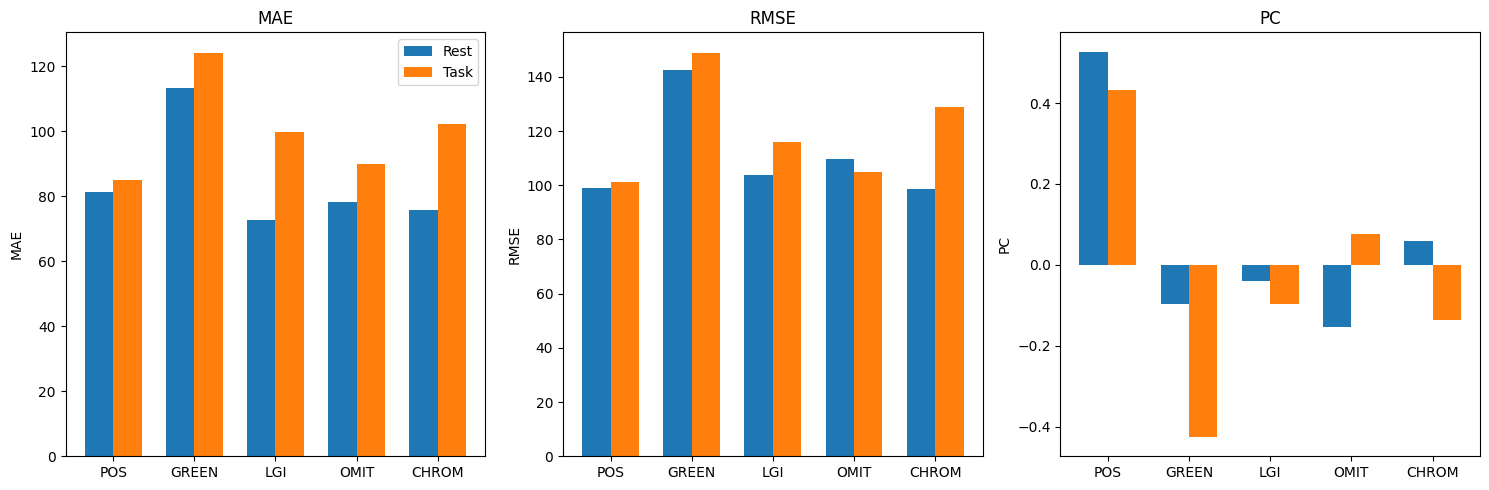

In [17]:
metrics = ["MAE", "RMSE", "PC"]
methods = ["POS", "GREEN", "LGI", "OMIT", "CHROM"]
x = range(len(methods))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, metric in enumerate(metrics):
    ax = axes[idx]
    rest_vals = eval_df_sdnn[eval_df_sdnn["Condition"]=="Rest"][metric]
    task_vals = eval_df_sdnn[eval_df_sdnn["Condition"]=="Task"][metric]
    ax.bar([i-width/2 for i in x], rest_vals, width, label="Rest")
    ax.bar([i+width/2 for i in x], task_vals, width, label="Task")
    ax.set_xticks(x)
    ax.set_xticklabels(methods)
    ax.set_ylabel(metric)
    ax.set_title(metric)
    if idx == 0:
        ax.legend()
plt.tight_layout()
plt.show()

| Method | MAE (Rest) | RMSE (Rest) | PC (Rest) | MAE (Task) | RMSE (Task) | PC (Task) |
|--------|------------|-------------|-----------|------------|-------------|-----------|
| POS    | 50.89      | 83.41       | 0.4546    | 70.89      | 95.17       | 0.2672    |
| GREEN  |113.42      |127.37       | 0.6198    | 94.20      |116.28       | 0.1734    |
| LGI    | 43.35      | 66.98       | 0.6697    | 69.93      | 80.68       | 0.3106    |
| OMIT   | 43.06      | 66.51       | 0.6768    | 69.84      | 81.59       | 0.2907    |
| CHROM  | 53.64      | 70.66       | 0.5486    | 72.87      | 86.82       | -0.0077   |

**Observation**

---

- HRV adalah ukuran variasi waktu antar detak jantung, sehingga membutuhkan ketelitian waktu yang lebih tinggi dibandingkan hanya menghitung rata-rata detak jantung (HR).

- Dalam evaluasi, HRV (misal SDNN) menunjukkan seberapa besar fluktuasi interval antar detak, bukan hanya jumlah detak per menit. Oleh karena itu, kualitas sinyal dan akurasi deteksi puncak sangat penting agar hasil HRV

- Pengukuran HRV seperti ini biasanya menggunakan metode kontak (EKG / PPG) yang memiliki error yang lebih rendah (MAE < 10ms) yang cocok dipakai.

- rPPG sebagai metode kontak tentu akan menghadapi error tambahan seperti delay, noise, dan aftifak gerakan. Penelitian sebelumnya berfokus pada pengukuran HRV melaporkan error SDNN / RMSSD 10 - 40 ms (Perbedaan dengan metode kontak PPG) [[1]](https://www.mdpi.com/2306-5354/10/7/851)[[2]](https://arxiv.org/pdf/2305.04161). Penggunaan korelasi (PC) juga digunakan untuk menilai konsistensi pengukuran SDNN ini.

- Pada kondisi istirahat, sama seperti pengukuran detak jantung, beberapa metode rPPG masih dapat mencapai korelasi moderat (PC > 0.6), meskipun MAE relatif tinggi (> 30–40 ms). Hal ini menunjukan rPPG dapat melakukan pengukuran HRV meskipun cederung overestimasi (dengan error yang relatif tinggi).

- Kondisi tugas/mental load: performa memburuk lebih jauh (MAE/RMSE meningkat, PC < 0.3), sehingga estimasi HRV tidak konsisten dengan referensi kontak. Penurunan performa ini disebabkan oleh gerakan wajah, ekspresi dan pencahayaan yang lebih bervariasi sama seperti pengukuran HR

- Kesimpulan: saat ini, rPPG belum cukup andal untuk mengukur nilai absolut HRV (seperti SDNN) di berbagai kondisi. Namun, pada skenario minim gerakan, rPPG masih bisa digunakan untuk memantau tren relatif (apakah HRV naik/turun) dibandingkan ground truth. Untuk mencapai presisi yang mendekati metode kontak, diperlukan pendekatan rekonstruksi sinyal yang lebih canggih 

- Namun secara general rPPG masih belum bisa untuk menangkap detail variabilitas detak jantung yang membutuhkan presisi tingkat lanjut serta reliabilitas yang masih kurang (Pearson Corr yang lemah)

#### Ekstraksi HRV (RMSSD)

---

In [18]:
rows = []

for subject in subjects:
    row = [subject]
    # Rest (T1) RMSSD
    for method in ["PPG", "POS", "GREEN", "LGI", "OMIT", "CHROM"]:
        val = df_metrics.query("Subject == @subject and Task == 'T1' and Method == @method")["RMSSD"]
        row.append(val.values[0] if len(val) > 0 else None)
    # Task (T3) RMSSD
    for method in ["PPG", "POS", "GREEN", "LGI", "OMIT", "CHROM"]:
        val = df_metrics.query("Subject == @subject and Task == 'T3' and Method == @method")["RMSSD"]
        row.append(val.values[0] if len(val) > 0 else None)

    rows.append(row)

df_rmssd = pd.DataFrame(rows, columns=columns)
print("RMSSD (Satuan: ms)")
df_rmssd

RMSSD (Satuan: ms)


Rest                            Task                           
   Subject   GT  POS GREEN  LGI OMIT CHROM   GT  POS GREEN  LGI OMIT CHROM
0      s41   64  183   191  135  136   132  348  278   364  256  281   257
1      s42  128  213   243  270  270   241  235  363   432  417  417   329
2      s43   53  213   349  197  197   189  243  336   433  358  382   300
3      s44  149  335   262  262  262   254  283  258   323  525  436   466
4      s45  145  236   385  251  251   243  155  380   465  450  452   408
5      s46   58  114    63   75   75   174  116  292   340  234  262   235
6      s47  104  140   270  106  106   110  335  402   192  168  475    15
7      s48  362  210   321  164  161   210  426  439   445  377  385   453
8      s49   47  195   143   88   88    75  428  403   426  402  372   382
9      s50   20  244   364  219  218   235   97  244   480  234  233   232
10     s51   91  135   176  107  108   181  177  241   401  291  296   324
11     s52   99  202   210  185  185   182  311  300   396  294  296   319
12     s53  157  173   126   89   90   107  345  292   389  267  267   323
13     s54  187  211   517  221  222   216  154  347   464  361  376   343
14     s55  207  559   394  353   15   433  153  397   516  433  428   522
15     s56  440  494    15   15   15   109  353  444   343  343  343    89

#### Evaluasi RMSSD (MAE, RMSE dan PC)

---

- **MAE** dan **RMSE** digunakan untuk mengukur seberapa besar perbedaan nilai RMSSD antara hasil estimasi rPPG dan referensi PPG.
- **PC (Pearson Correlation)** digunakan untuk melihat tren atau korelasi antara hasil pengukuran RMSSD dari rPPG dan PPG.

In [19]:
methods = ["POS", "GREEN", "LGI", "OMIT", "CHROM"]
conditions = ["Rest", "Task"]

eval_results = []

for cond in conditions:
    gt = df_rmssd[(cond, "GT")]  # ground truth for this condition
    for method in methods:
        row=[method]
        pred = df_rmssd[(cond, method)]
        
        mae = mean_absolute_error(gt, pred)
        rmse = np.sqrt(np.mean((gt - pred) ** 2))
        pc, _ = pearsonr(gt, pred)
        
        eval_results.append({
            "Condition": cond,
            "Method": method,
            "MAE": mae,
            "RMSE": rmse,
            "PC": pc
        })

eval_df_rmssd = pd.DataFrame(eval_results)
eval_df_rmssd

,Condition,Method,MAE,RMSE,PC
0,Rest,POS,115.6250,143.543547,0.573728
1,Rest,GREEN,169.5000,207.538249,-0.096145
2,Rest,LGI,113.0000,151.265082,-0.130589
3,Rest,OMIT,116.1250,154.627779,-0.293319
4,Rest,CHROM,115.3750,141.220130,0.075641
5,Task,POS,101.5625,125.285424,0.424348
6,Task,GREEN,160.0000,205.829116,-0.371505
7,Task,LGI,133.0625,159.055611,0.018695
8,Task,OMIT,129.7500,153.757114,0.134176
9,Task,CHROM,145.2500,180.144040,-0.097468


**Visualisasi Hasil MAE, RMSE dan PC**

---

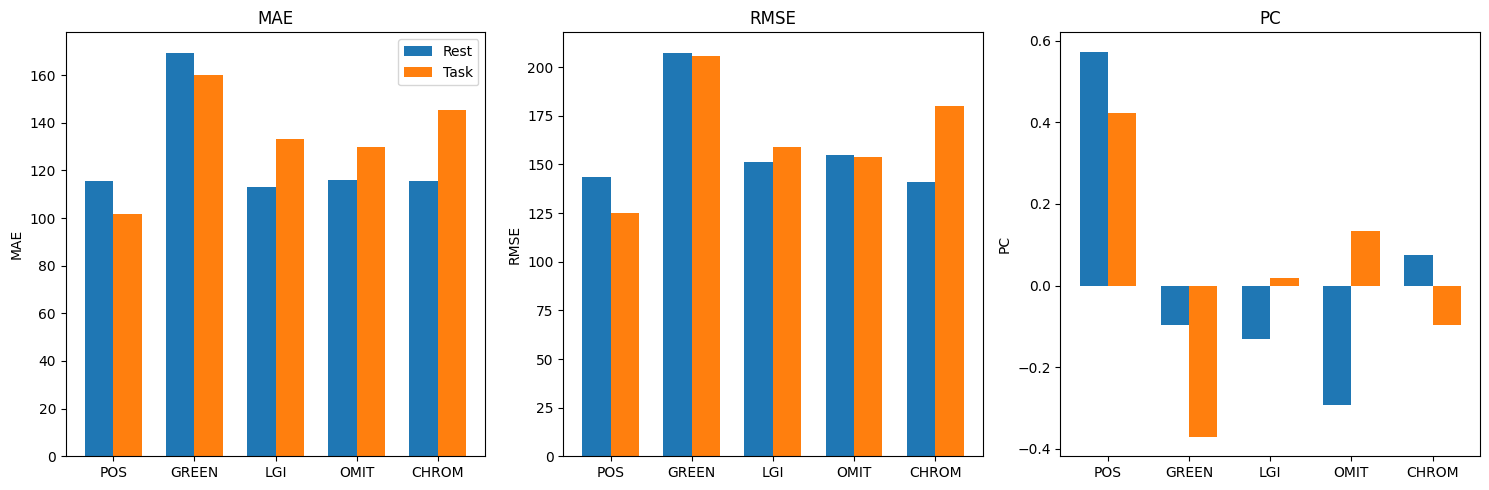

In [20]:
metrics = ["MAE", "RMSE", "PC"]
methods = ["POS", "GREEN", "LGI", "OMIT", "CHROM"]
x = range(len(methods))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, metric in enumerate(metrics):
    ax = axes[idx]
    rest_vals = eval_df_rmssd[eval_df_rmssd["Condition"]=="Rest"][metric]
    task_vals = eval_df_rmssd[eval_df_rmssd["Condition"]=="Task"][metric]
    ax.bar([i-width/2 for i in x], rest_vals, width, label="Rest")
    ax.bar([i+width/2 for i in x], task_vals, width, label="Task")
    ax.set_xticks(x)
    ax.set_xticklabels(methods)
    ax.set_ylabel(metric)
    ax.set_title(metric)
    if idx == 0:
        ax.legend()
plt.tight_layout()
plt.show()

| Method | MAE (Rest) | RMSE (Rest) | PC (Rest) | MAE (Task) | RMSE (Task) | PC (Task) |
|--------|------------|-------------|-----------|------------|-------------|-----------|
| POS    | 63.88      |104.86       | 0.5589    | 99.94      |130.87       | 0.2401    |
| GREEN  |159.25      |180.08       | 0.6639    |133.81      |160.21       | 0.0719    |
| LGI    | 51.94      | 80.50       | 0.7389    | 93.94      |109.39       | 0.3029    |
| OMIT   | 52.69      | 79.93       | 0.7521    | 94.13      |110.00       | 0.3005    |
| CHROM  | 74.00      | 90.42       | 0.5858    |106.00      |120.75       | -0.1035   |

**Observation**

---

- RMSSD adalah metrik HRV yang mengukur variasi jeda waktu antar detak jantung. Seperti SDNN, RMSSD membutuhkan ketelitian waktu tinggi karena fokusnya pada perubahan waktu antar detak, bukan hanya jumlah detak.
- Pada kondisi tugas mental, performa rPPG menurun, baik dari sisi error maupun konsistensi pola (Pearson Correlation).
- Secara umum, rPPG kurang cocok untuk mengukur HRV secara non-kontak di berbagai skenario karena sangat sensitif terhadap gerakan dan pencahayaan, sehingga presisi hasil HRV sulit

### Overall Checks: Visualisasi Hasil MAE, RMSE, dan PC

---

Evaluasi awal dilakukan untuk menilai sejauh mana metode rPPG mampu merekonstruksi sinyal fisiologis dibandingkan sinyal referensi PPG. Penilaian dilakukan pada dua skenario (Rest dan Task) dengan tiga metrik utama: HR, SDNN, dan RMSSD. Setiap metode rPPG dievaluasi menggunakan indikator statistik (MAE, RMSE, dan Pearson Correlation).

Hasil evaluasi ini menjadi dasar untuk:
1. Menentukan metode rPPG yang relatif paling konsisten pada kedua skenario.  
2. Mengidentifikasi metrik fisiologis yang lebih stabil untuk digunakan pada tahap analisis berikutnya.  

Secara umum, **HR menunjukkan kecenderungan lebih reliabel** dibanding SDNN dan RMSSD, dengan performa lebih baik pada MAE, RMSE, dan PC. Di antara metode rPPG, **POS dan CHROM tampil lebih konsisten terutama pada estimasi HR**, meskipun performa estimasi HRV masih bervariasi dan dari hasil pengukuran, error yang dihasilkan masih cukup tinggi untuk dapat digunakan sebagai alternatif.

Berdasarkan hal ini, analisis selanjutnya difokuskan pada **HR** sebagai metrik utama. Fokus ini tidak hanya karena keunggulan teknis (error lebih rendah), tetapi juga karena HR lebih relevan sebagai indikator fisiologis terhadap peningkatan beban mental. Dengan demikian, tahap berikutnya akan memvisualisasikan perbedaan antara kondisi Rest dan Task pada level kelompok maupun individu.


## Analisis : Tugas Istirahat vs Tugas Mental

---

Karena HR (Heart Rate) merupakan satu-satunya metrik yang paling reliabel dari hasil estimasi, maka analisis selanjutnya akan difokuskan pada pengaruh kondisi Rest dan Task terhadap nilai HR.

Visualisasi berikut akan menunjukkan bagaimana perubahan HR terjadi antara kondisi istirahat (Rest) dan tugas (Task), baik pada level kelompok maupun individu.

---

### Analisis Tingkat Kelompok

Melihat pengaruh kondisi tugas terhadap peningkatan HR secara keseluruhan pada kelompok subjek.

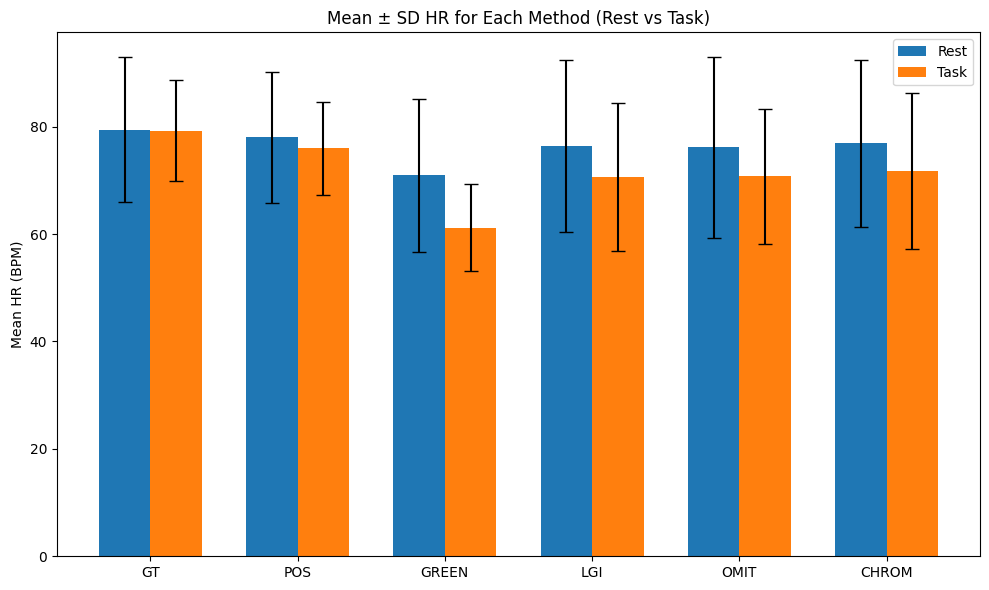

In [21]:
methods = ["GT", "POS", "GREEN", "LGI", "OMIT", "CHROM"]
conditions = ["Rest", "Task"]

mean_vals = []
std_vals = []
for cond in conditions:
    for method in methods:
        vals = df_hr[(cond, method)].values
        mean_vals.append(np.mean(vals))
        std_vals.append(np.std(vals))

# Reshape for plotting
mean_vals = np.array(mean_vals).reshape(2, len(methods))
std_vals = np.array(std_vals).reshape(2, len(methods))

x = np.arange(len(methods))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))
bars_rest = ax.bar(x - width/2, mean_vals[0], width, yerr=std_vals[0], capsize=5, label='Rest')
bars_task = ax.bar(x + width/2, mean_vals[1], width, yerr=std_vals[1], capsize=5, label='Task')

ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylabel("Mean HR (BPM)")
ax.set_title("Mean ± SD HR for Each Method (Rest vs Task)")
ax.legend()
plt.tight_layout()
plt.show()

In [22]:
methods = ["GT", "POS", "GREEN", "LGI", "OMIT", "CHROM"]
conditions = ["Rest", "Task"]

# Calculate mean and std for each method and condition
summary = pd.DataFrame(index=methods)
for cond in conditions:
    stats = df_hr[cond].agg(["mean", "std"])
    summary[f"{cond} Mean"] = stats.loc["mean"].values
    summary[f"{cond} STD"] = stats.loc["std"].values

summary

,Rest Mean,Rest STD,Task Mean,Task STD
GT,79.4375,13.885094,79.2500,9.705668
POS,78.0000,12.649111,75.9375,8.910434
GREEN,70.9375,14.712665,61.1875,8.344409
LGI,76.4375,16.560873,70.6250,14.272935
OMIT,76.1250,17.346950,70.7500,12.928006
CHROM,76.8750,16.103312,71.6875,15.009858


**Observasi dan Analisis**

---

- Berdasarkan data rata-rata (mean) dan standar deviasi (STD) detak jantung dari metode kontak (PPG/GT), tidak ditemukan perbedaan signifikan antara kondisi istirahat (Rest) dan tugas mental (Task). Nilai rata-rata HR hampir sama (Rest: 79.44 bpm, Task: 79.25 bpm).

- Studi lebih lanjut dengan jumlah data yang lebih besar diperlukan agar efek statistik dapat terlihat lebih jelas.

- Metode rPPG cenderung menghasilkan estimasi pengukuran HR yang lebih tinggi (overestimasi) atau lebih rendah (underestimasi) dibandingkan GT, dengan rata-rata HR yang relatif tinggi pada kedua skenario.

- Karena secara statistik belum terlihat perbedaan yang jelas, analisis intrasubjek diperlukan untuk mengetahui apakah PPG dan rPPG mampu menangkap perubahan fisiologis individu saat mengalami beban mental.

### Analisis Intrasubjek

Melihat bagaimana Respons Individu terhadap Pengaruh tugas istirahat dan mental

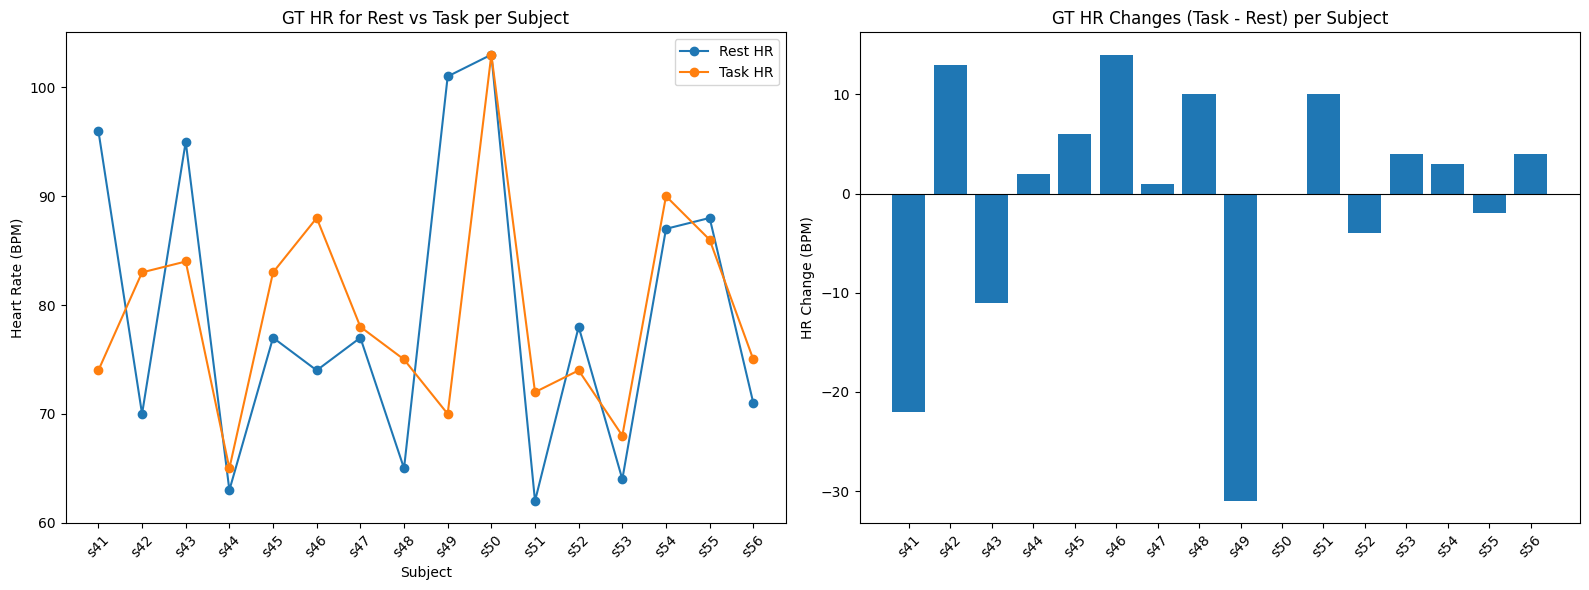

,Subject,Rest_GT,Task_GT,Delta_GT
0,s41,96,74,-22
1,s42,70,83,13
2,s43,95,84,-11
3,s44,63,65,2
4,s45,77,83,6
5,s46,74,88,14
6,s47,77,78,1
7,s48,65,75,10
8,s49,101,70,-31
9,s50,103,103,0


In [23]:
subjects = df_hr[("", "Subject")].values if ("", "Subject") in df_hr.columns else df_hr.index
rest_hr = df_hr[("Rest", "GT")].values
task_hr = df_hr[("Task", "GT")].values
delta_hr = task_hr - rest_hr

import pandas as pd
df_ind = pd.DataFrame({
    "Subject": subjects,
    "Rest_GT": rest_hr,
    "Task_GT": task_hr,
    "Delta_GT": delta_hr
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Line chart
axes[0].plot(df_ind["Subject"], df_ind["Rest_GT"], marker="o", label="Rest HR")
axes[0].plot(df_ind["Subject"], df_ind["Task_GT"], marker="o", label="Task HR")
axes[0].set_title("GT HR for Rest vs Task per Subject")
axes[0].set_xlabel("Subject")
axes[0].set_ylabel("Heart Rate (BPM)")
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Bar chart
axes[1].bar(df_ind["Subject"], df_ind["Delta_GT"])
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("GT HR Changes (Task - Rest) per Subject")
axes[1].set_ylabel("HR Change (BPM)")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

df_ind[["Subject","Rest_GT","Task_GT","Delta_GT"]]

**Metode POS**

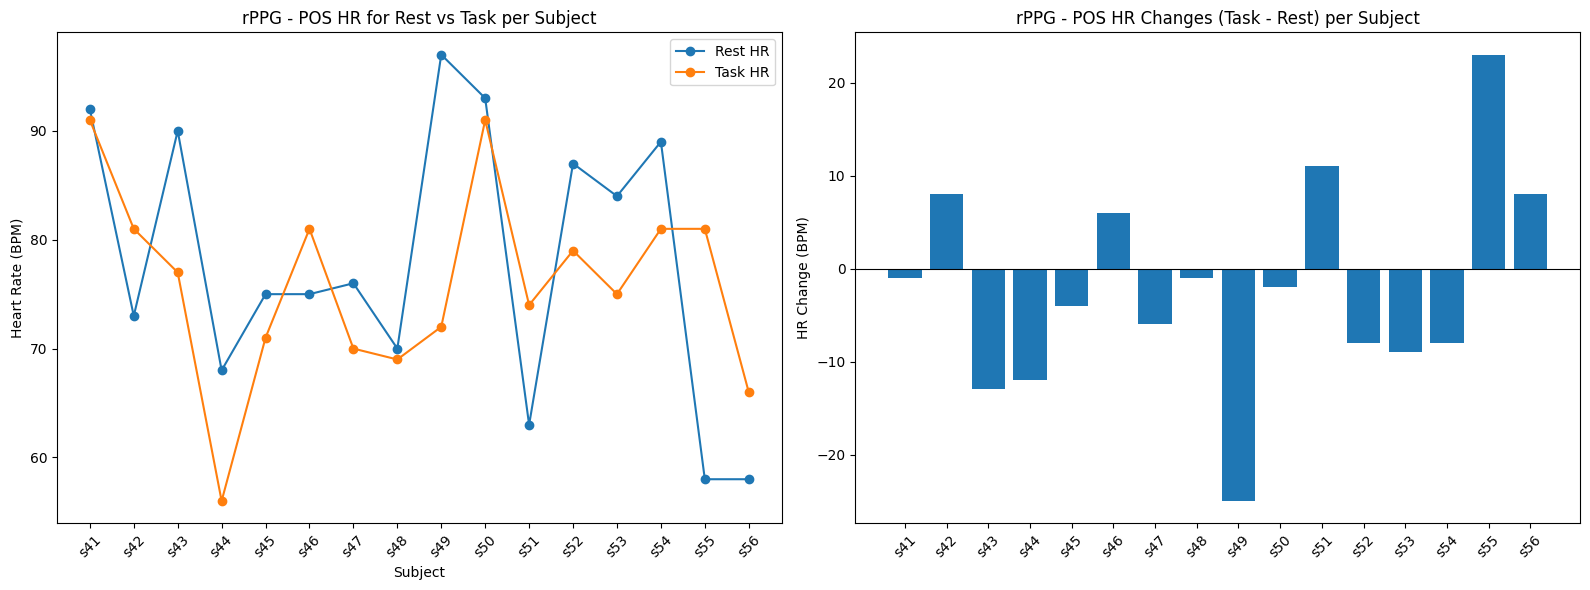

,Subject,Rest_POS,Task_POS,Delta_POS
0,s41,92,91,-1
1,s42,73,81,8
2,s43,90,77,-13
3,s44,68,56,-12
4,s45,75,71,-4
5,s46,75,81,6
6,s47,76,70,-6
7,s48,70,69,-1
8,s49,97,72,-25
9,s50,93,91,-2


In [24]:
subjects = df_hr[("", "Subject")].values if ("", "Subject") in df_hr.columns else df_hr.index
rest_hr = df_hr[("Rest", "POS")].values
task_hr = df_hr[("Task", "POS")].values
delta_hr = task_hr - rest_hr

import pandas as pd
df_ind = pd.DataFrame({
    "Subject": subjects,
    "Rest_POS": rest_hr,
    "Task_POS": task_hr,
    "Delta_POS": delta_hr
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Line chart
axes[0].plot(df_ind["Subject"], df_ind["Rest_POS"], marker="o", label="Rest HR")
axes[0].plot(df_ind["Subject"], df_ind["Task_POS"], marker="o", label="Task HR")
axes[0].set_title("rPPG - POS HR for Rest vs Task per Subject")
axes[0].set_xlabel("Subject")
axes[0].set_ylabel("Heart Rate (BPM)")
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Bar chart
axes[1].bar(df_ind["Subject"], df_ind["Delta_POS"])
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("rPPG - POS HR Changes (Task - Rest) per Subject")
axes[1].set_ylabel("HR Change (BPM)")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

df_ind[["Subject","Rest_POS","Task_POS","Delta_POS"]]

**Metode CHROM**

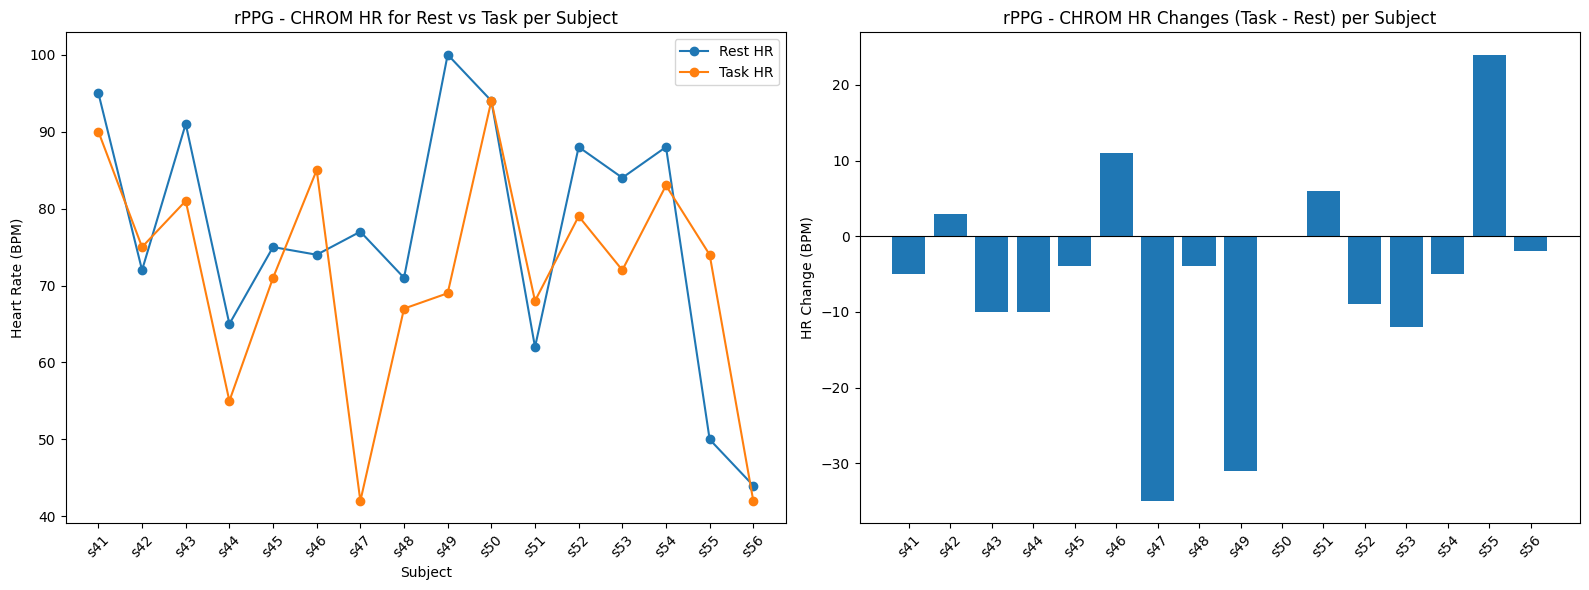

,Subject,Rest_CHROM,Task_CHROM,Delta_CHROM
0,s41,95,90,-5
1,s42,72,75,3
2,s43,91,81,-10
3,s44,65,55,-10
4,s45,75,71,-4
5,s46,74,85,11
6,s47,77,42,-35
7,s48,71,67,-4
8,s49,100,69,-31
9,s50,94,94,0


In [25]:
subjects = df_hr[("", "Subject")].values if ("", "Subject") in df_hr.columns else df_hr.index
rest_hr = df_hr[("Rest", "CHROM")].values
task_hr = df_hr[("Task", "CHROM")].values
delta_hr = task_hr - rest_hr

import pandas as pd
df_ind = pd.DataFrame({
    "Subject": subjects,
    "Rest_CHROM": rest_hr,
    "Task_CHROM": task_hr,
    "Delta_CHROM": delta_hr
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Line chart
axes[0].plot(df_ind["Subject"], df_ind["Rest_CHROM"], marker="o", label="Rest HR")
axes[0].plot(df_ind["Subject"], df_ind["Task_CHROM"], marker="o", label="Task HR")
axes[0].set_title("rPPG - CHROM HR for Rest vs Task per Subject")
axes[0].set_xlabel("Subject")
axes[0].set_ylabel("Heart Rate (BPM)")
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Bar chart
axes[1].bar(df_ind["Subject"], df_ind["Delta_CHROM"])
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("rPPG - CHROM HR Changes (Task - Rest) per Subject")
axes[1].set_ylabel("HR Change (BPM)")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

df_ind[["Subject","Rest_CHROM","Task_CHROM","Delta_CHROM"]]

### Konsistensi Pola antara GT & rPPG

- Secara individu, baik data PPG maupun rPPG saat mengukur HR (detak jantung) menunjukkan variasi respons yang berbeda ketika subjek berada dalam beban mental.

- Sebagian subjek mengalami peningkatan detak jantung, sementara yang lain mengalami penurunan, baik pada plot data HR menggunakan metode kontak (PPG) maupun non-kontak (rPPG, POS dan CHROM) yang relatif stabil terhadap tugas mental.

- Hal ini mendukung teori psikofisiologis bahwa respons individu terhadap beban mental memang bervariasi secara fisiologis, namun diperlukan data lebih banyak agar efek statistik dapat terlihat lebih

## Diskusi Keseluruhan

---

### Implikasi terhadap beban mental

Berdasarkan hasil analisis HR pada kondisi istirahat dan tugas mental, secara umum terlihat adanya kecenderungan peningkatan detak jantung saat subjek menghadapi beban kognitif, meskipun respons intrasubjek menunjukkan variasi. Temuan ini mendukung teori psikofisiologis bahwa peningkatan beban mental berkaitan dengan peningkatan aktivasi fisiologis.

Namun, karena penelitian ini melibatkan jumlah subjek yang terbatas (N = 16), generalisasi hasil masih perlu diuji pada populasi yang lebih luas dan dengan variasi tugas kognitif yang berbeda. Penelitian lanjutan juga penting untuk mengeksplorasi kombinasi metrik lain seperti HRV, agar pemahaman mengenai respons fisiologis terhadap stres kognitif menjadi lebih komprehensif.

### Keterbatasan metode rPPG

Metode rPPG menawarkan keunggulan karena mampu mengukur sinyal fisiologis hanya dengan kamera, tanpa sensor kontak langsung. Namun, penerapannya masih menghadapi beberapa keterbatasan.

Pertama, rPPG sangat sensitif terhadap pergerakan. Kondisi ideal ketika subjek benar-benar diam tidak selalu dapat dicapai, bahkan dalam lingkungan kerja yang terkontrol. Hal ini dapat memengaruhi akurasi estimasi detak jantung. Hal ini dibuktikan ketika terdapat penurunan error yang lebih tinggi ketika mengukur subjek dalam tugas mental

Kedua, rPPG memiliki keterbatasan dalam mengukur metrik psikofisiologis yang lebih kompleks seperti HRV. Estimasi HRV menuntut presisi tinggi dan stabilitas sinyal, sementara rPPG masih rentan terhadap noise, sehingga hasilnya kurang konsisten dibandingkan dengan sensor kontak langsung seperti PPG atau ECG.

### Konsep PoC

Berdasarkan hasil ini, akan dibuat sebuah PoC dengan menggunakan metode POS / CHROM karena metode ini masih cukup tahan (robust) pada dua kondisi yang berbeda sehingga cocok untuk melakukan monitoring terhadap individu.